# Basic Charts in Python

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# Load the dataset (replace 'path_to_file' with the actual path)
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# `.info()`

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


# Scatterplots

This plot can help visualize the relationship between two numerical variables, such as housing median age vs. median house value.

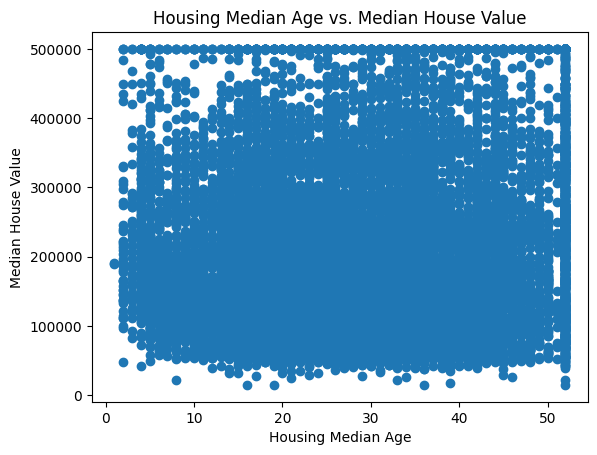

In [41]:
plt.scatter(df['housing_median_age'], df['median_house_value'])
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.title('Housing Median Age vs. Median House Value')
plt.show()


# Histograms

A histogram helps to display the distribution of a single numerical variable, such as housing median age.

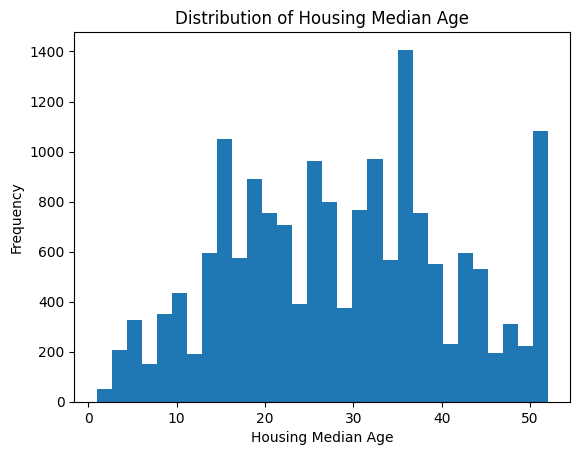

In [42]:
plt.hist(df['housing_median_age'], bins=30)
plt.xlabel('Housing Median Age')
plt.ylabel('Frequency')
plt.title('Distribution of Housing Median Age')
plt.show()

Here's another variable you can try - median income! Just don't forget to update the axes.

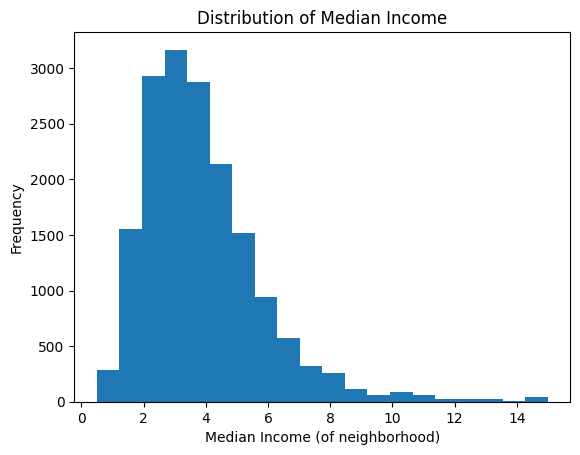

In [43]:
plt.hist(df['median_income'], bins=20)
plt.xlabel('Median Income (of neighborhood)')
plt.ylabel('Frequency')
plt.title('Distribution of Median Income')
plt.show()

# Boxplots

This plot helps visualize the distribution of a numerical variable across different categories, such as median house value for different ocean proximity categories.

## Make your own boolean variable!

In [44]:
df['FLAG_income'] = np.where(df['median_income'] > 3,
                             1, # if TRUE
                             0) # if FALSE

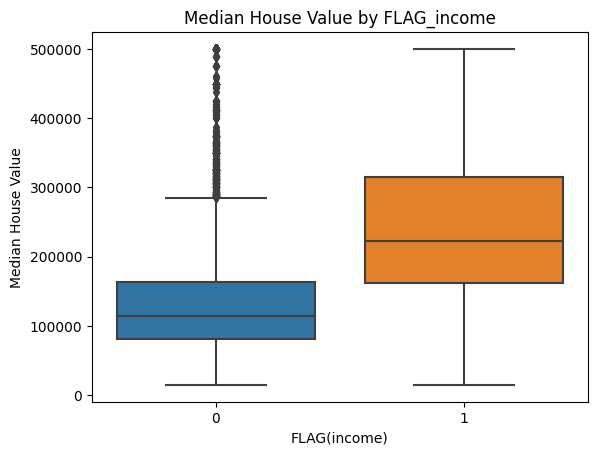

In [45]:
import seaborn as sns

sns.boxplot(x='FLAG_income', y='median_house_value', data=df)
plt.xlabel('FLAG(income)')
plt.ylabel('Median House Value')
plt.title('Median House Value by FLAG_income')
plt.show()


# Correlation Heatmap

This plot helps visualize the correlation between different numerical variables in the dataset.

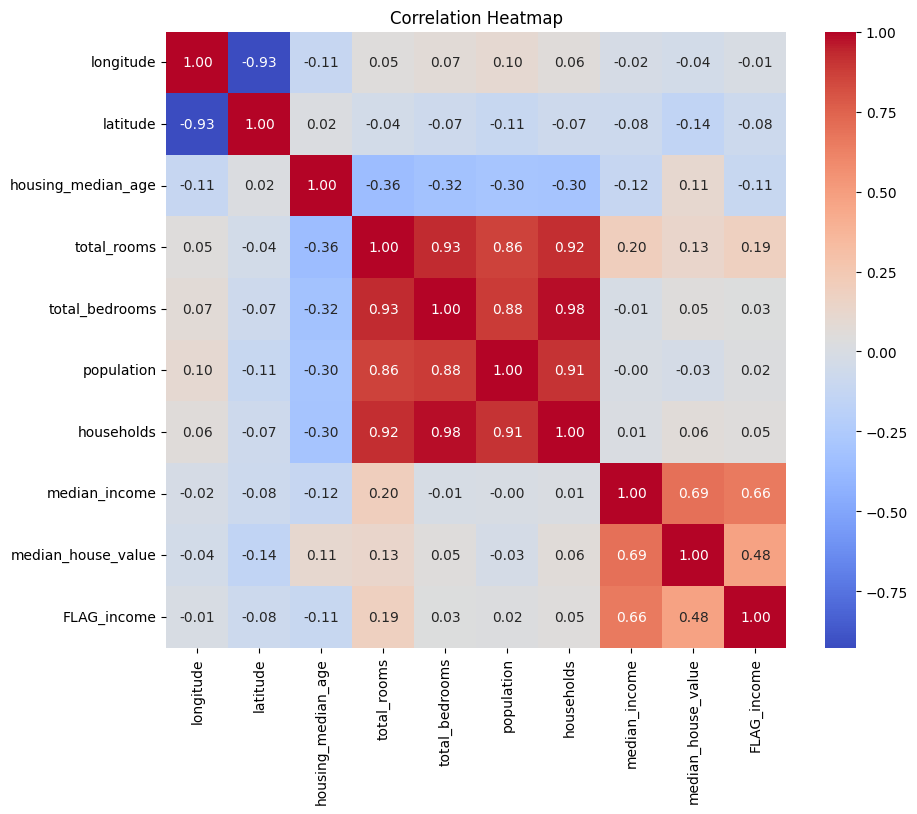

In [46]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Bar Chart

A bar chart can represent categorical data, such as the count of houses for different FLAG(income) categories.

## First attempt...

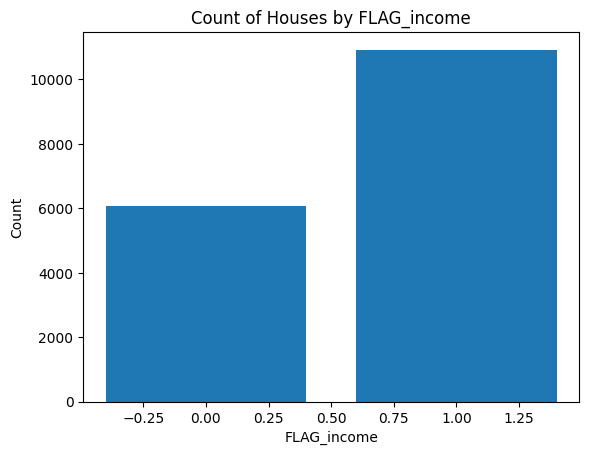

In [47]:
the_counts = df['FLAG_income'].value_counts()

plt.bar(the_counts.index, the_counts.values)
plt.xlabel('FLAG_income')
plt.ylabel('Count')
plt.title('Count of Houses by FLAG_income')
plt.show()


💡Hmmm... doesn't that X axis look a bit strange? It's because of the data type! Let's make it categorical (string) to clean it up a bit.

## Second attempt...

In [48]:
df['FLAG_income'] = np.where(df['median_income'] > 3,
                             '1', # if TRUE
                             '0') # if FALSE

Now run the updated code again.

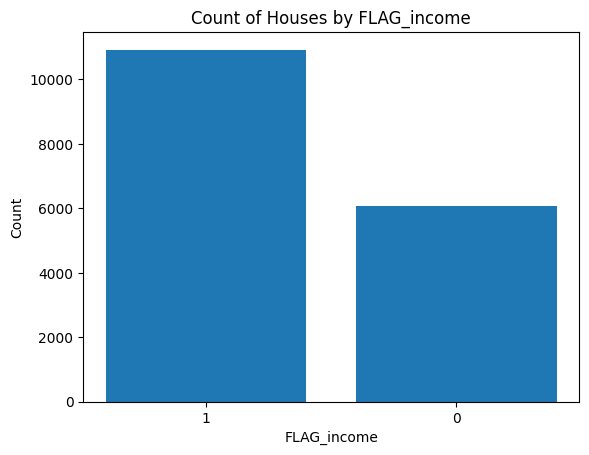

In [49]:
the_counts = df['FLAG_income'].value_counts()

plt.bar(the_counts.index, the_counts.values)
plt.xlabel('FLAG_income')
plt.ylabel('Count')
plt.title('Count of Houses by FLAG_income')
plt.show()


Oh no! It still isn't giving us what we want. Why? It's sorting by the frequency column and goes from lowest to highest. We can sort and try again.

## Third attempt...

In [50]:
the_counts = pd.DataFrame(the_counts)
the_counts.head()

,FLAG_income
1,10923
0,6077


Now sort by the index!

In [51]:
the_counts.sort_index(ascending=True, inplace=True)

Check your work...

In [53]:
the_counts

,FLAG_income
0,6077
1,10923


In [57]:
the_counts.index.values

array(['0', '1'], dtype=object)

In [58]:
the_counts.values

array([[ 6077],
       [10923]])

And re-run your code with a **light update!** 😀 We need to reference the column of data we generated (it's called `FLAG_income`)

In [63]:
the_counts['FLAG_income']

0     6077
1    10923
Name: FLAG_income, dtype: int64

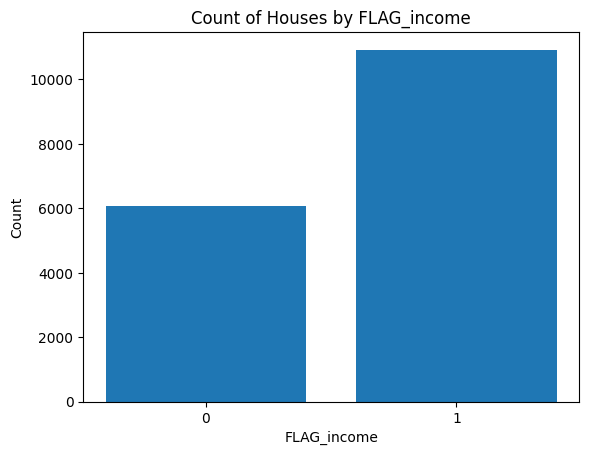

In [62]:
plt.bar(the_counts.index, the_counts['FLAG_income'])
plt.xlabel('FLAG_income')
plt.ylabel('Count')
plt.title('Count of Houses by FLAG_income')
plt.show()

This example was a bit long - but in the real-world, it is stuff like this that happens ALL THE TIME where you show your value. The other two plots were junk!

# Bubble Chart

For a bubble chart, let's consider 'housing_median_age' against 'median_house_value' with 'population' determining bubble size:

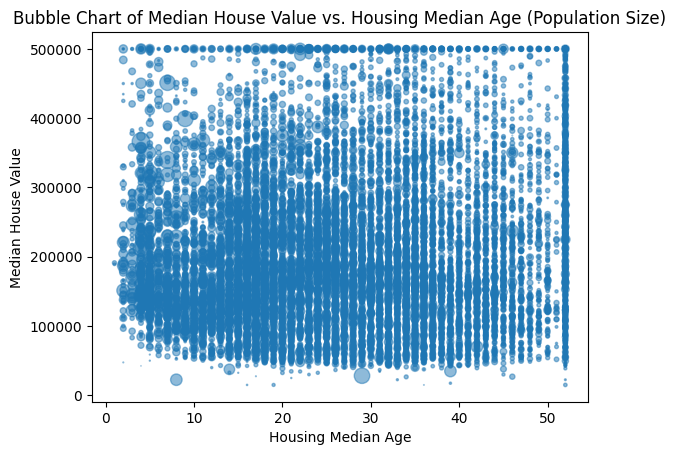

In [64]:
plt.scatter(df['housing_median_age'], df['median_house_value'], s=df['population']/100, alpha=0.5)
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.title('Bubble Chart of Median House Value vs. Housing Median Age (Population Size)')
plt.show()

This graph is... fine... but doesn't tell us much. Let's try to find a better pattern...

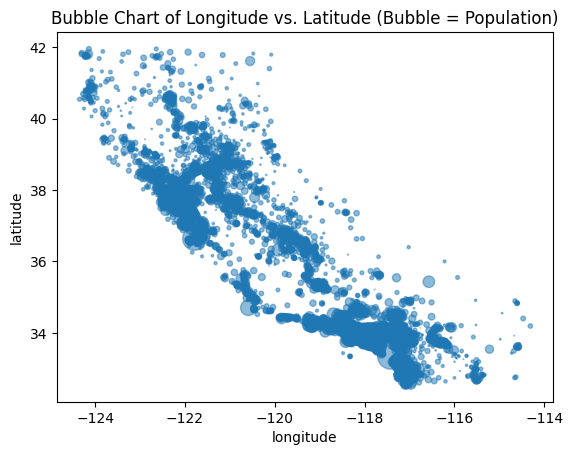

In [67]:
plt.scatter(df['longitude'], df['latitude'], s=df['population']/100, alpha=0.5)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('Bubble Chart of Longitude vs. Latitude (Bubble = Population)')
plt.show()

You can customize this code a lot!

*   Add new colors for different categories
*   Add a legend
*   Add a basemap (so you can see the World behind it!)



# Area Chart

An area chart can show changes in numerical values over a continuous interval, for example, 'median_income' over 'housing_median_age':

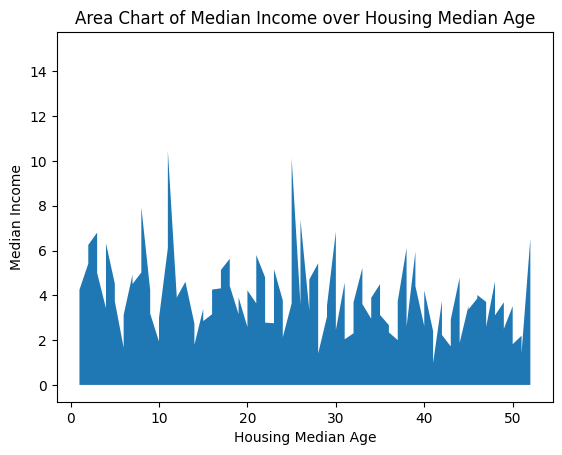

In [68]:
df.sort_values('housing_median_age', inplace=True)

plt.fill_between(df['housing_median_age'], df['median_income'])
plt.xlabel('Housing Median Age')
plt.ylabel('Median Income')
plt.title('Area Chart of Median Income over Housing Median Age')
plt.show()


Versus here is just the raw scatterplot.

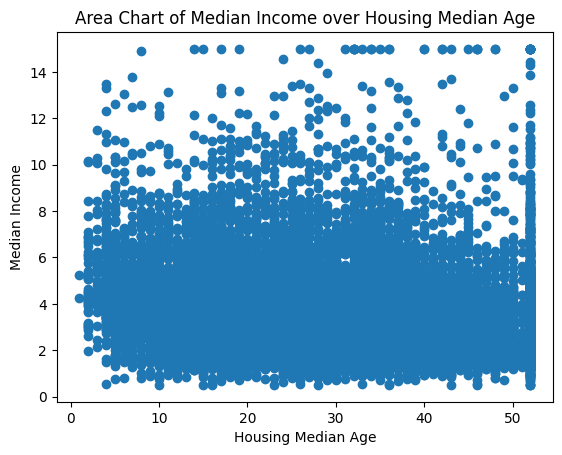

In [70]:
plt.scatter(df['housing_median_age'], df['median_income'])
plt.xlabel('Housing Median Age')
plt.ylabel('Median Income')
plt.title('Area Chart of Median Income over Housing Median Age')
plt.show()

# Pie Chart

A pie chart can show the proportion of different categories, for instance, the percentage of houses based on ocean proximity:A pie chart can show the proportion of different categories, for instance, the percentage of houses based on ocean proximity:

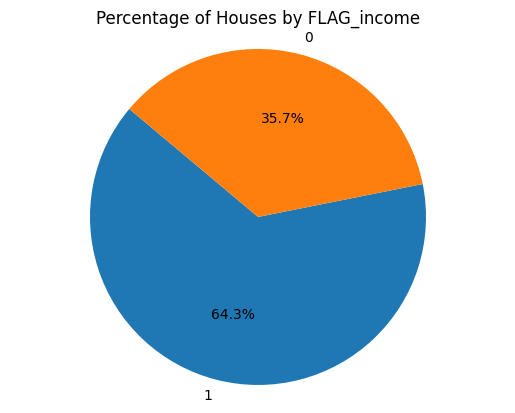

In [72]:
the_counts = df['FLAG_income'].value_counts()

plt.pie(the_counts, labels=the_counts.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Percentage of Houses by FLAG_income')
plt.show()
